## Title: Cars24 Price Prediction

# Objective
To develop an end-to-end machine learning system that predicts used car prices and provides actionable market intelligence insights to support data-driven decision-making in the automobile resale industry

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import sys
import os
sys.path.append(os.path.abspath(".."))

In [2]:
df = pd.read_csv(r"c:\Users\sangu\OneDrive\Desktop\Excler Project\cars24_data.csv")
df.head()

,name,make,model,city,year,fueltype,kilometerdriven,ownernumber,transmission,bodytype,storename,isc24assured,registrationcity,registrationstate,benefits,discountprice,price,url,createdDate
0,Hyundai Elite i20,Hyundai,Elite I20,Kochi,2017,Petrol,35939,2,Manual,Hatchback,Kochi-Pns,False,Kozhikode,Kerala,13898,47399,607000,https://www.cars24.com/buy-used-hyundai-elite-...,2022-03-24
1,Maruti Alto 800,Maruti,Alto 800,Mumbai,2016,Petrol + Cng,6180,1,Manual,Hatchback,Hi-West Mumbai,False,Mumbai,Maharashtra,12542,2099,326000,https://www.cars24.com/buy-used-maruti-alto-80...,2022-11-09
2,Maruti Dzire,Maruti,Dzire,Lucknow,2019,Petrol + Cng,46808,1,Manual,Sedan,Vibhuti Khand - Gomti Nagar,False,Lucknow,Uttar Pradesh,13898,26000,640000,https://www.cars24.com/buy-used-maruti-dzire-2...,2022-09-30
3,KIA SELTOS,Kia,Seltos,Bangalore,2020,Diesel,26045,1,Manual,SUV,Bengaluru-Pns,False,Bengaluru,Karnataka,9688,143700,1354000,https://www.cars24.com/buy-used-kia-seltos-202...,2022-07-04
4,Maruti Ertiga,Maruti,Ertiga,Kolkata,2017,Petrol,53056,1,Manual,SUV,Hi-Kolkata,False,Barrackpore,West Bengal,13898,22800,676000,https://www.cars24.com/buy-used-maruti-ertiga-...,2022-10-28


# EDA

In [3]:
df.shape

(6437, 19)

In [4]:
df.columns

Index(['name', 'make', 'model', 'city', 'year', 'fueltype', 'kilometerdriven',
       'ownernumber', 'transmission', 'bodytype', 'storename', 'isc24assured',
       'registrationcity', 'registrationstate', 'benefits', 'discountprice',
       'price', 'url', 'createdDate'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6437 entries, 0 to 6436
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   name               6437 non-null   str  
 1   make               6437 non-null   str  
 2   model              6437 non-null   str  
 3   city               6437 non-null   str  
 4   year               6437 non-null   int64
 5   fueltype           6437 non-null   str  
 6   kilometerdriven    6437 non-null   int64
 7   ownernumber        6437 non-null   int64
 8   transmission       6061 non-null   str  
 9   bodytype           6062 non-null   str  
 10  storename          6437 non-null   str  
 11  isc24assured       6437 non-null   bool 
 12  registrationcity   6437 non-null   str  
 13  registrationstate  6437 non-null   str  
 14  benefits           6437 non-null   int64
 15  discountprice      6437 non-null   int64
 16  price              6437 non-null   int64
 17  url                6437 n

FInding null values

In [6]:
df.isnull().sum()

name                   0
make                   0
model                  0
city                   0
year                   0
fueltype               0
kilometerdriven        0
ownernumber            0
transmission         376
bodytype             375
storename              0
isc24assured           0
registrationcity       0
registrationstate      0
benefits               0
discountprice          0
price                  0
url                    0
createdDate            0
dtype: int64

In [7]:
df.describe()

,year,kilometerdriven,ownernumber,benefits,discountprice,price
count,6437.000000,6437.000000,6437.000000,6437.000000,6437.000000,6.437000e+03
mean,2017.636166,41568.066335,1.235669,12079.200559,23500.592512,6.781378e+05
std,2.656825,26187.115364,0.454501,2458.162316,41579.296564,3.450395e+05
min,2008.000000,64.000000,1.000000,9688.000000,-155500.000000,1.340000e+05
25%,2016.000000,20580.000000,1.000000,9688.000000,-100.000000,4.390000e+05
50%,2018.000000,38177.000000,1.000000,12542.000000,10600.000000,5.880000e+05
75%,2020.000000,59333.000000,1.000000,13898.000000,37000.000000,8.290000e+05
max,2022.000000,455601.000000,3.000000,19407.000000,388300.000000,3.048000e+06


VISUAL EDA INSIGHTS 

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Premium theme
sns.set_theme(style="whitegrid", context="talk")

# Bigger + consistent figures
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11

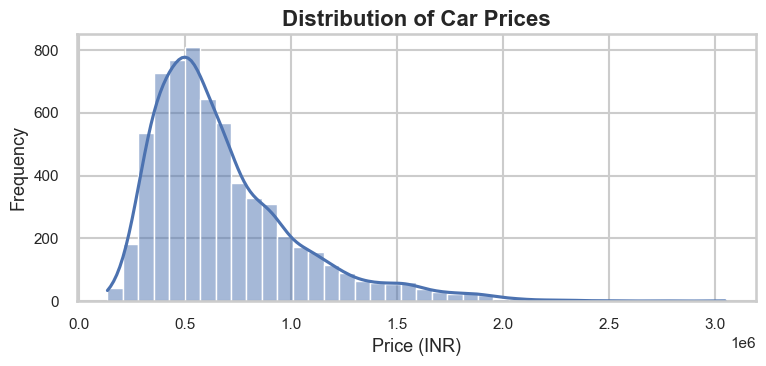

In [9]:
plt.figure(figsize=(8,4))
sns.histplot(df['price'], kde=True, color='#4C72B0', bins=40)
plt.title("Distribution of Car Prices", fontweight='bold')
plt.xlabel("Price (INR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

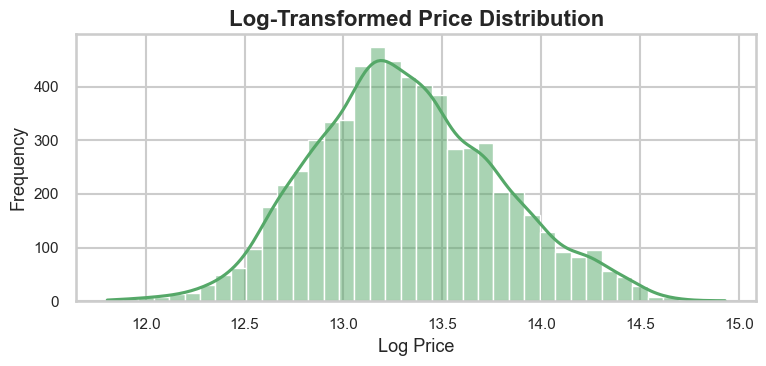

In [10]:
plt.figure(figsize=(8,4))
sns.histplot(np.log1p(df['price']), kde=True, color='#55A868', bins=40)
plt.title("Log-Transformed Price Distribution", fontweight='bold')
plt.xlabel("Log Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

This indicates that most used cars are affordable, while luxury cars create a long tail.
 Log transformation may improve model performance.

Car depreciation is a strong factor affecting resale value.
 car_age is a highly important feature for prediction.

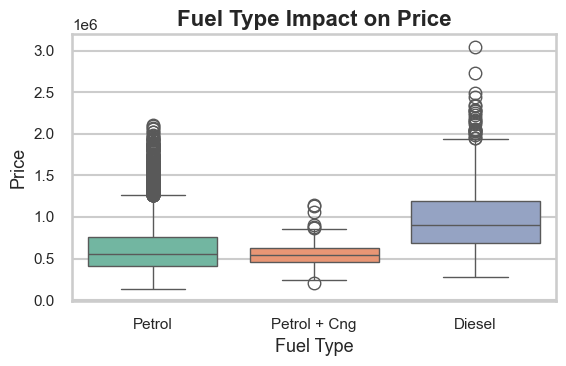

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x='fueltype',
    y='price',
    data=df,
    palette='Set2'
)
plt.title("Fuel Type Impact on Price", fontweight='bold')
plt.xlabel("Fuel Type")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

Fuel type significantly influences price due to performance, mileage, and demand.
 Important categorical feature.

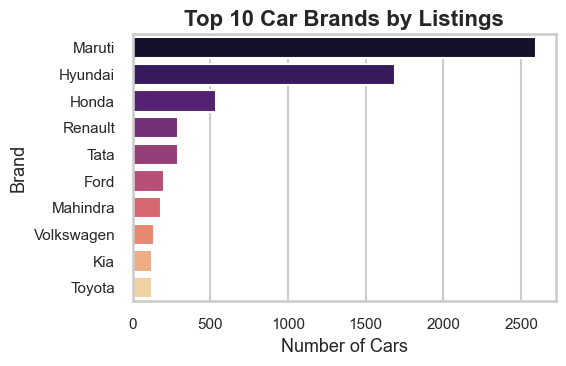

In [12]:
plt.figure(figsize=(6,4))
top_brands = df['make'].value_counts().head(10)
sns.barplot(
    x=top_brands.values,
    y=top_brands.index,
    palette='magma'
)
plt.title("Top 10 Car Brands by Listings", fontweight='bold')
plt.xlabel("Number of Cars")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

Dataset is skewed toward mass-market brands
 Model may bias toward common brands

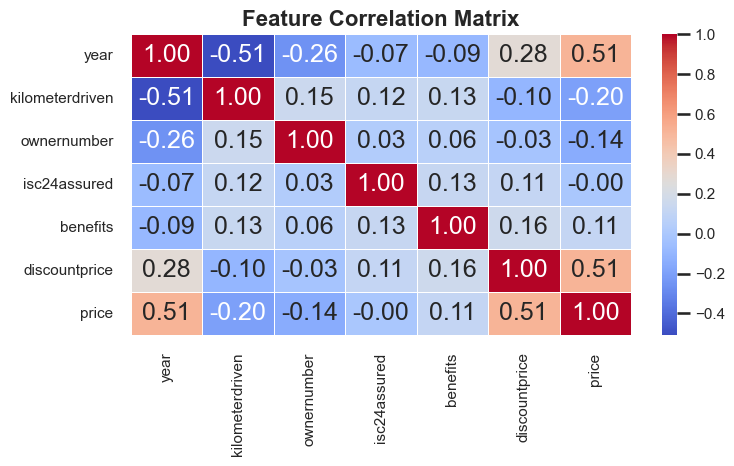

In [13]:
plt.figure(figsize=(8,5))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title("Feature Correlation Matrix", fontweight='bold')
plt.tight_layout()
plt.show()

No single feature dominates — multiple factors contribute

The resale price of a car is influenced by a combination of age, usage, brand, fuel type, and ownership history.
Depreciation and brand positioning are the strongest drivers of pricing in the used car market.

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6437 entries, 0 to 6436
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   name               6437 non-null   str  
 1   make               6437 non-null   str  
 2   model              6437 non-null   str  
 3   city               6437 non-null   str  
 4   year               6437 non-null   int64
 5   fueltype           6437 non-null   str  
 6   kilometerdriven    6437 non-null   int64
 7   ownernumber        6437 non-null   int64
 8   transmission       6061 non-null   str  
 9   bodytype           6062 non-null   str  
 10  storename          6437 non-null   str  
 11  isc24assured       6437 non-null   bool 
 12  registrationcity   6437 non-null   str  
 13  registrationstate  6437 non-null   str  
 14  benefits           6437 non-null   int64
 15  discountprice      6437 non-null   int64
 16  price              6437 non-null   int64
 17  url                6437 n

# Preprocessed Data

In [15]:
from src.data_preprocessing import preprocess_data
df_processed = preprocess_data(df, training=True)
df_processed.head()

,year,kilometerdriven,ownernumber,isc24assured,benefits,discountprice,price,fueltype_Petrol,fueltype_Petrol + Cng,transmission_Manual,...,city_Others,city_Pune,registrationstate_Gujarat,registrationstate_Karnataka,registrationstate_Maharashtra,registrationstate_Others,registrationstate_Rajasthan,registrationstate_Tamil Nadu,registrationstate_Telangana,registrationstate_Uttar Pradesh
0,2017,35939,2,0,13898,47399,607000,1,0,1,...,1,0,0,0,0,1,0,0,0,0
1,2016,6180,1,0,12542,2099,326000,0,1,1,...,0,0,0,0,1,0,0,0,0,0
2,2019,46808,1,0,13898,26000,640000,0,1,1,...,0,0,0,0,0,0,0,0,0,1
3,2020,26045,1,0,9688,143700,1354000,0,0,1,...,0,0,0,1,0,0,0,0,0,0
4,2017,53056,1,0,13898,22800,676000,1,0,1,...,0,0,0,0,0,1,0,0,0,0


In [16]:
df_processed.info()

<class 'pandas.DataFrame'>
RangeIndex: 6422 entries, 0 to 6421
Data columns (total 55 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   year                             6422 non-null   int64
 1   kilometerdriven                  6422 non-null   int64
 2   ownernumber                      6422 non-null   int64
 3   isc24assured                     6422 non-null   int64
 4   benefits                         6422 non-null   int64
 5   discountprice                    6422 non-null   int64
 6   price                            6422 non-null   int64
 7   fueltype_Petrol                  6422 non-null   int64
 8   fueltype_Petrol + Cng            6422 non-null   int64
 9   transmission_Manual              6422 non-null   int64
 10  bodytype_Luxury SUV              6422 non-null   int64
 11  bodytype_Luxury Sedan            6422 non-null   int64
 12  bodytype_SEDAN                   6422 non-null   int64
 13 

In [17]:
from src.feature_engineering import feature_engineering
df_final = feature_engineering(df_processed, training=True)


🔹 Top correlated features with price:
price                  1.000000
discountprice          0.512342
year                   0.511741
bodytype_SUV           0.479882
make_Others            0.333615
model_Others           0.305418
make_Mahindra          0.236163
bodytype_Luxury SUV    0.222641
model_Creta            0.218123
make_Tata              0.162896
Name: price, dtype: float64


In [18]:
from src.train_model import train_model
results, models = train_model(df_final)
results


🔹 Training Linear Regression...

🔹 Training Ridge Regression...

🔹 Training Lasso Regression...

🔹 Training Random Forest...

🔹 Training XGBoost...


,Model,R2 Score,RMSE,MAE,CV Mean,CV Std
4,XGBoost,0.8530,137611.54,86859.48,0.8424,0.0062
3,Random Forest,0.8351,145750.11,84600.64,0.8343,0.0088
0,Linear Regression,0.7530,178375.91,119844.15,0.7493,0.0166
2,Lasso Regression,0.7530,178375.91,119844.15,0.7493,0.0166
1,Ridge Regression,0.7530,178375.50,119842.74,0.7494,0.0165


In [19]:
from src.save_artifacts import save_artifacts
save_artifacts(models, df_final)

✅ All deployment artifacts saved inside root /models folder


In [20]:
from importlib import reload
import src.predict_pipeline
reload(src.predict_pipeline)

from src.predict_pipeline import predict_price

In [21]:
#pip install plotly

In [22]:
from src.visualization import plot_all

plot_all(results, models, df_final)

In [25]:
car_a = {
    'make': 'Hyundai',
    'model': 'Creta',
    'city': 'Bangalore',
    'year': 2022,
    'fueltype': 'Petrol',
    'kilometerdriven': 18000,
    'ownernumber': 1,
    'transmission': 'Automatic',
    'bodytype': 'SUV',
    'isc24assured': 1,
    'registrationstate': 'Karnataka'
}
print(predict_price(car_a))

1460816.88


In [26]:
car_b = {
    'make': 'Hyundai',
    'model': 'Creta',
    'city': 'Bangalore',
    'year': 2015,
    'fueltype': 'Petrol',
    'kilometerdriven': 110000,
    'ownernumber': 3,
    'transmission': 'Manual',
    'bodytype': 'SUV',
    'isc24assured': 0,
    'registrationstate': 'Karnataka'
}
print(predict_price(car_b))

812513.5


In [28]:
car_c = {
    'make': 'Maruti',
    'model': 'Alto 800',
    'city': 'Bangalore',
    'year': 2020,
    'fueltype': 'Petrol',
    'kilometerdriven': 30000,
    'ownernumber': 1,
    'transmission': 'Manual',
    'bodytype': 'HATCHBACK',
    'isc24assured': 1,
    'registrationstate': 'Karnataka'
}
print(predict_price(car_c))

540177.31


In [30]:
car_e = {
    'make': 'Honda',
    'model': 'City',
    'city': 'Delhi',
    'year': 2019,
    'fueltype': 'Petrol',
    'kilometerdriven': 42000,
    'ownernumber': 1,
    'transmission': 'Automatic',
    'bodytype': 'SEDAN',
    'isc24assured': 1,
    'registrationstate': 'Delhi'
}
print(predict_price(car_e))

865097.31


In [31]:
car_f = car_e.copy()
car_f['city'] = 'Others'
print(predict_price(car_f))

834755.5


In [32]:
car_g = car_e.copy()
car_g['ownernumber'] = 4
print(predict_price(car_g))

820269.94
